In [2]:
# Standard scientific imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
import json
import os
# Import your SNN model + firing structure
from SNN_GA.snnmoo.snn import SNN, SNNFirings
from typing import Dict, List, Tuple, Any

C:\Users\Divse\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


CASE 1 : 10EXC 2INH 
This block loads the GA‑optimised parameters for the first case

In [ ]:
# Load GA parameter file for Case 1
# NOTE: update path as per local relative path
params_path = "SNN_GA/results/snn_ga_1k/ex10_in2_20260409-235242/params.json"
with open(params_path) as f:
    params = json.load(f)
# Extract best candidate parameters
best = params["best_candidate"]
ge = best["ge"]               # excitatory weight
gi = best["gi"]               # inhibitory weight
sp = best["sparsity"]         # connectivity sparsity
th_ex = best["thalamic_ex"]   # thalamic drive to excitatory
th_in = best["thalamic_in"]   # thalamic drive to inhibitory
validated_comp = best["composite"]  # composite RMSE score

In [ ]:
# Base seed offset for evaluation trials
SEED_BASE_EVAL = 1000

# GA target values (from params.json)
ex_target = params["ex_target"]
in_target = params["in_target"]
psd_target = params["psd_peak_target"]

# Seeds used for repeated evaluation trials
trial_seeds = np.arange(params["trials_per_candidate"]) + SEED_BASE_EVAL

# Storage for trial‑wise metrics
ex_vals = []
in_vals = []
psd_vals = []

# Time resolution and analysis window (200–1000 ms)
dt = 1/1000
start_index = int(0.2/dt)
end_index = int(1.0/dt)

def rfft_psd_peak(I_sum: np.ndarray, start_index: int, end_index: int, dt: float = 1.0/1000.0) -> Tuple[float, np.ndarray, np.ndarray]:
    """
    Compute PSD peak frequency using rFFT.
    Matches the GA's PSD computation method.
    Returns:
        peak_freq : float
        faxis     : frequency axis
        Sxx       : PSD values
    """
    X = I_sum[start_index:end_index] - np.mean(I_sum[start_index:end_index])
    N = len(X)
    if N <= 1:
        return 0.0, np.array([0.0]), np.array([0.0])
    # Apply Hanning window to reduce spectral leakage
    xf = np.fft.rfft(X * np.hanning(N))

    # PSD normalisation consistent with GA
    Sxx = np.real((2 * dt**2 / (N * dt)) * (xf * np.conj(xf)))

    # Frequency axis
    faxis = np.fft.rfftfreq(N, d=dt)

    # Peak frequency
    peak_freq = float(faxis[np.argmax(Sxx)])
    return peak_freq, faxis, Sxx

# Run evaluation trials using the GA‑optimised parameters
for seed in trial_seeds:
    # Instantiate SNN with best parameters
    model = SNN(ge=ge, gi=gi, sparsity=sp, thalamic_ex=th_ex, thalamic_in=th_in)

    # Run network with given seed
    result = model.run_network(seed=int(seed))

    # Extract firing rates
    s = result.score()
    ex_vals.append(s["ex_firing"])
    in_vals.append(s["in_firing"])

    # Compute PSD peak for this trial
    peak, _, _ = rfft_psd_peak(result.I_sum, start_index, end_index, dt=dt)
    psd_vals.append(peak)

# Convert lists → arrays
ex_vals = np.array(ex_vals)
in_vals = np.array(in_vals)
psd_vals = np.array(psd_vals)

# Compute raw RMSEs in GA objective space
rmse_ex_raw = np.sqrt(np.mean((ex_vals - ex_target)**2))
rmse_in_raw = np.sqrt(np.mean((in_vals - in_target)**2))
rmse_psd_raw = np.sqrt(np.mean((psd_vals - psd_target)**2))

# Normalise by target values (GA uses normalised RMSE)
ex_norm = rmse_ex_raw / ex_target
in_norm = rmse_in_raw / in_target
psd_norm = rmse_psd_raw / psd_target

print("GA-space coordinates for validated candidate:")
print("ex_norm =", ex_norm)
print("in_norm =", in_norm)
print("psd_norm =", psd_norm)

GA-space coordinates for validated candidate:
ex_norm = 0.043322596075595084
in_norm = 0.13552319527790557
psd_norm = 0.2507488783623967


In [ ]:
import plotly.graph_objects as go
# Load the full Pareto frontier for Case 1
# NOTE: update path as per local relative path
path = "SNN_GA/results/snn_ga_1k/ex10_in2_20260409-235242/frontier_full.csv"
df = pd.read_csv(path)

# Extract normalised RMSE columns
exc = df["ex_firing_error_norm"]
inh = df["inhib_firing_error_norm"]
psd = df["psd_peak_error_norm"]

# Compute overall normalised RMSE (L2 norm)
rmse_total = np.sqrt(exc**2 + inh**2 + psd**2)

# Create 3D scatter plot of the Pareto frontier
fig = go.Figure()
# MAIN FRONTIER POINTS
fig.add_trace(go.Scatter3d(
    x=exc,
    y=inh,
    z=psd,
    mode='markers',
    marker=dict(
        size=5,
        color=rmse_total, # colour by composite RMSE
        colorscale='Viridis',
        colorbar=dict(
            title = dict( text = "<br>Normalised Overall RMSE", side = "bottom" ),
            orientation="h",     # horizontal colourbar
            x=0.5,               # center horizontally
            y=0.05,             # place below the plot
            thickness=20,
            len=0.5,
            tickmode="array",
            tickvals=[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0],
            ticktext=["1.0", "1.5", "2.0", "2.5", "3.0", "3.5", "4.0", "4.5"]
        ),
        opacity=0.9
    ),
    hovertemplate=(
        "RMSEexc: %{x:.3f}<br>"
        "RMSEinh: %{y:.3f}<br>"
        "RMSEfreq: %{z:.3f}<br>"
        "Overall: %{marker.color:.3f}<br>"
        "<extra></extra>"
    ),
    showlegend=False,
    name=""
))

# VALIDATED BEST POINT
# This highlights the GA‑selected best candidate in the 3D space
fig.add_trace(go.Scatter3d(
    x=[ex_norm],
    y=[in_norm],
    z=[psd_norm],
    mode='markers',
    marker=dict(
        size=5,
        color=[validated_comp], # colour by composite score
        colorscale='Viridis',
        opacity=1.0
    ),
    hovertemplate=(
        "Lowest overall RMSE of %{marker.color:.3f}<br>"
        "RMSEexc: %{x:.3f}<br>"
        "RMSEinh: %{y:.3f}<br>"
        "RMSEfreq: %{z:.3f}<br>"
        "<extra></extra>"
    ),
    showlegend=False,
    name=""
))
# Layout adjustments for readability
fig.update_layout(
    scene=dict(
        domain=dict(
            x=[0.0, 1.0],
            y=[0.15, 1.0]   # only reserve 25% for colorbar, not 40–50%
        ),
        xaxis=dict(
            title=dict(text="Normalised excitatory RMSE", font=dict(size=26)),
            tickfont=dict(size=20)
        ),
        yaxis=dict(
            title=dict(text="Normalised inhibitory RMSE", font=dict(size=26)),
            tickfont=dict(size=20)
        ),
        zaxis=dict(
            title=dict(text="Normalised frequency RMSE", font=dict(size=26)),
            tickfont=dict(size=20)
        ),
    ),
    scene_camera=dict(
        eye=dict(x=1.8, y=2.2, z=1.5)   # lifts z-axis title
    ),
    margin=dict(l=0, r=0, t=0, b=0),   # remove unnecessary whitespace
    width=1100,
    height=950,
    showlegend=False
)

# Increase colourbar font sizes
fig.data[0].marker.colorbar.title.font = dict(size=30)
fig.data[0].marker.colorbar.tickfont = dict(size=24)

fig.show()

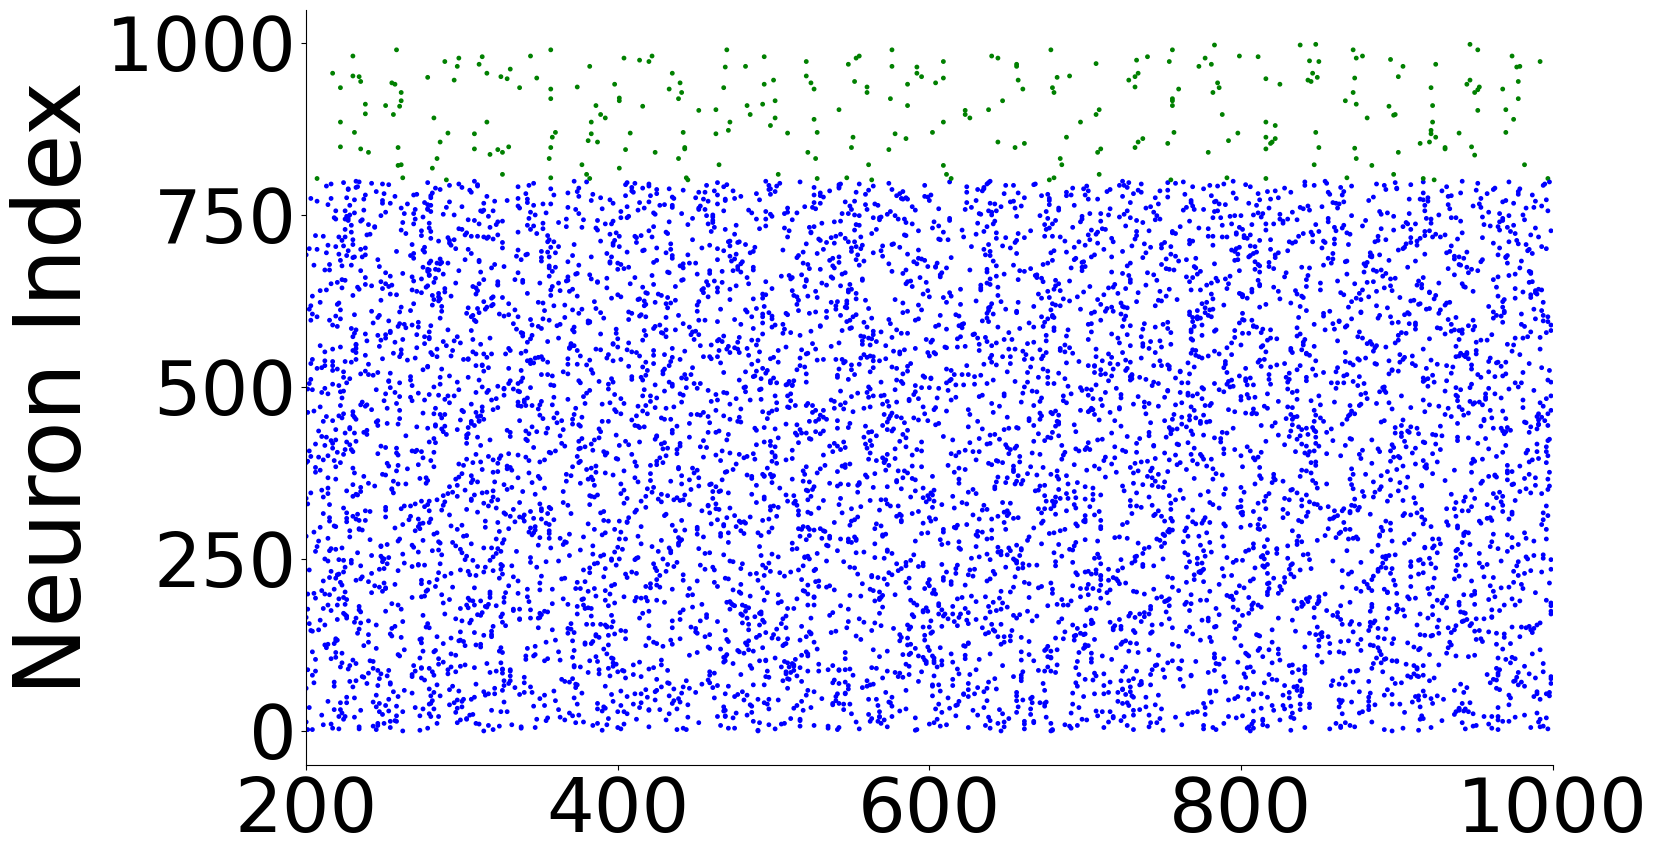

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Raster plot reconstruction for a selected trial
# NOTE: update path as per local relative path
npz_path = "SNN_GA/results/snn_ga_1k/ex10_in2_20260409-235242/gen25_trial10_raster.npz"
Ne = 800                               # number of excitatory neurons
Ni = 200                               # number of inhibitory neurons
dt = 1.0 / 1000.0                      # seconds per step
start_index = 0                        
end_index = None                       
# Load raster data
data = np.load(npz_path, allow_pickle=True)
firings_time = data["firings_time"]    # list of spikes per timestep
firings_neuron = data["firings_neuron"]  # spikes per neuron

# Convert (time → list of neurons) into explicit (t, n) pairs
points = []
for t, fired in enumerate(firings_time):
    for n in fired:
        points.append((t, n))

if not points:
    raise RuntimeError("No spikes found in this trial.")

points = np.array(points)
t_idx = points[:, 0]
n_idx = points[:, 1]

# Correct GA analysis window: 200–1000 ms
dt = 1.0 / 1000.0
start_index = int(0.2 / dt)   # 200 ms
end_index   = int(1.0 / dt)   # 1000 ms

mask = (t_idx >= start_index) & (t_idx < end_index)
t_idx = t_idx[mask]
n_idx = n_idx[mask]


# Colour excitatory (blue) vs inhibitory (green)
colors = np.where(n_idx >= Ne, "green", "blue")
# High‑resolution plotting settings
plt.rcParams.update({
    "font.size": 54,            # was 18
    "axes.titlesize": 66,       # was 22
    "axes.labelsize": 66,       # was 22
    "xtick.labelsize": 54,      # was 18
    "ytick.labelsize": 54,      # was 18
    "legend.fontsize": 38,      # was 14
    "figure.titlesize": 66,     # was 22
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(18, 10))

# Convert timestep → ms
times_ms = t_idx * dt * 1000.0
ax.set_xlim(200, 1000)
ax.set_xticks([200, 400, 600, 800, 1000])
ax.set_xlabel("Time (ms)")
# Scatter raster
ax.scatter(times_ms, n_idx, s=6, c=colors)

# Styling
ax.set_ylabel("Neuron Index")
# no x-axis label
ax.set_xlabel("") # intentionally blank for figure style

plt.tight_layout()
plt.show()


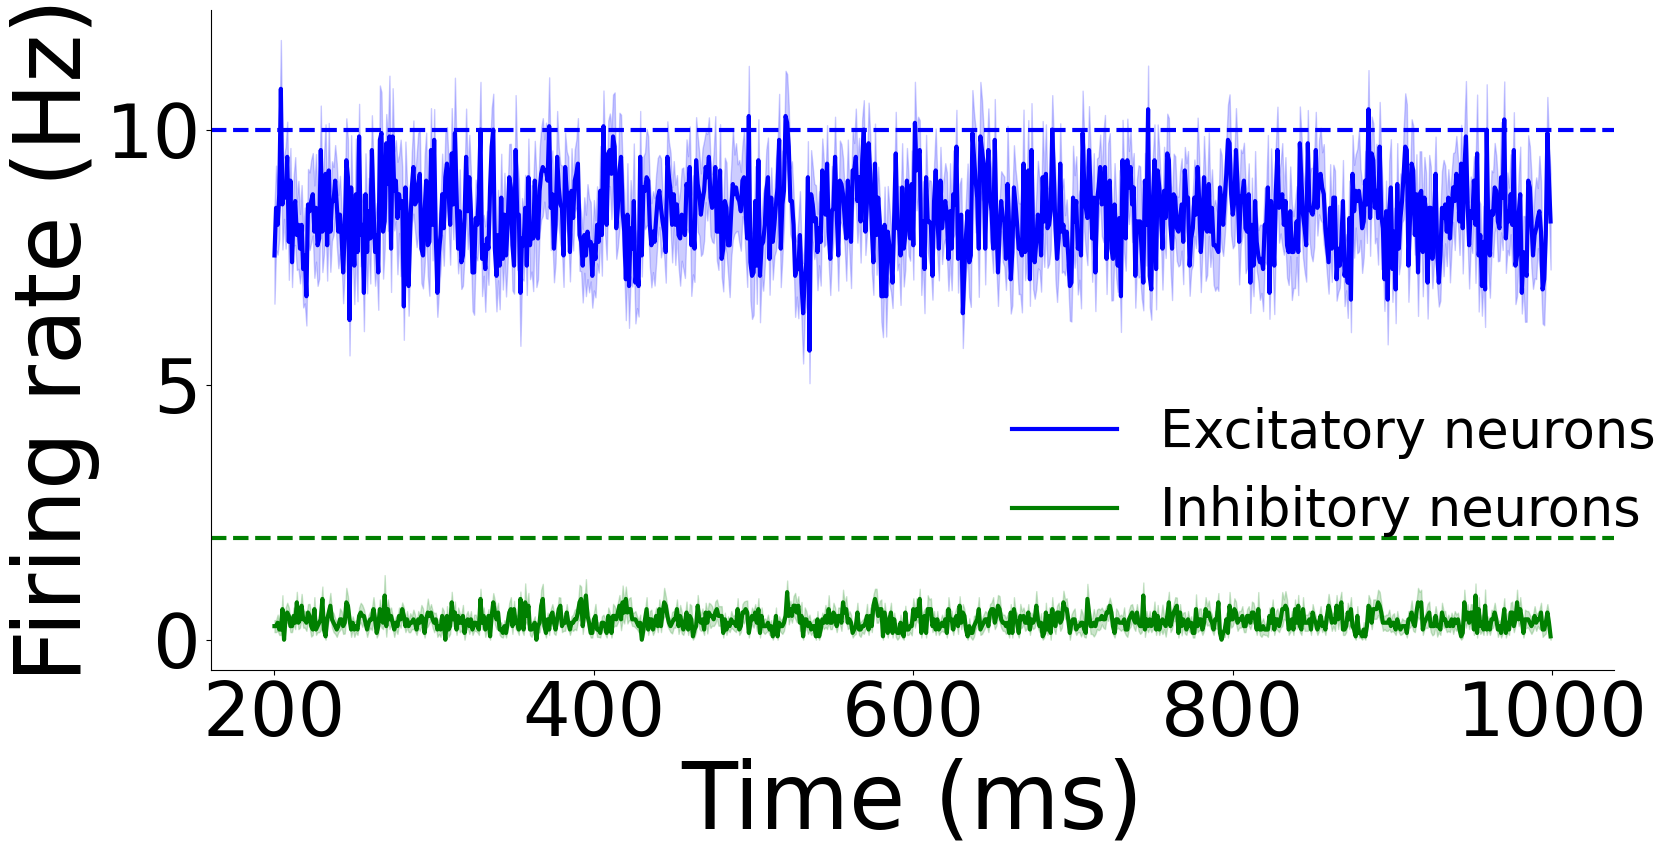

In [ ]:
# High‑resolution figure settings
plt.rcParams.update({
    "font.size": 54,            
    "axes.titlesize": 66,       
    "axes.labelsize": 66,      
    "xtick.labelsize": 54,      
    "ytick.labelsize": 54,      
    "legend.fontsize": 38,      
    "figure.titlesize": 66,     
    "axes.spines.top": False,
    "axes.spines.right": False,
})
# Load averaged firing‑rate data
# NOTE: update path as per local relative path
path = "SNN_GA/results/snn_ga_1k/ex10_in2_20260409-235242/avg_firing_rates_gen25.npz"
data = np.load(path)

time_axis = data["time_axis"]
ex_mean = data["ex_mean"]
in_mean = data["in_mean"]
ex_sem = data["ex_sem"]
in_sem = data["in_sem"]

fig, ax = plt.subplots(figsize=(18,10))

# Excitatory
ax.plot(time_axis, ex_mean, color="blue", label="Excitatory neurons", linewidth=3)
ax.fill_between(time_axis, ex_mean-ex_sem, ex_mean+ex_sem, color="blue", alpha=0.2)

# Inhibitory
ax.plot(time_axis, in_mean, color="green", label="Inhibitory neurons", linewidth=3)
ax.fill_between(time_axis, in_mean-in_sem, in_mean+in_sem, color="green", alpha=0.2)

# Target lines (from GA)
ax.axhline(10, color="blue", linestyle="--", linewidth=3)   # EX target
ax.axhline(2,  color="green", linestyle="--", linewidth=3)   # IN target

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Firing rate (Hz)")
# Legend positioned inside plot
legend = ax.legend(
    loc="center",
    bbox_to_anchor=(0.80, 0.30),   # right side, ~3 Hz
    bbox_transform=ax.transAxes,
    frameon=False,
    fontsize=38
)
legend.set_in_layout(False)
plt.tight_layout()
plt.show()


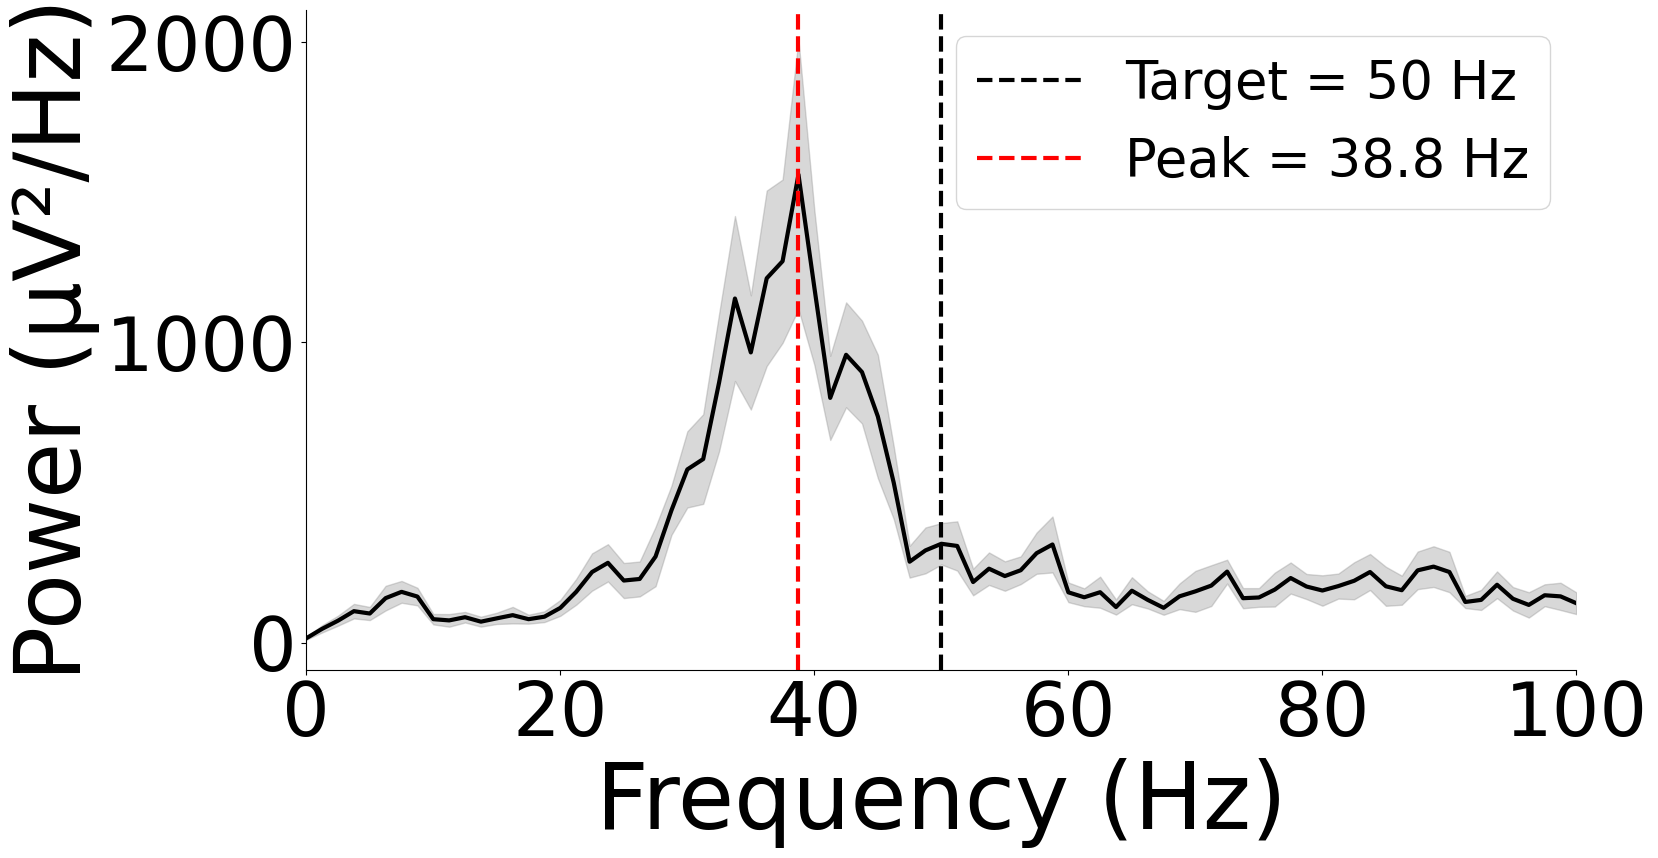

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 54,            
    "axes.titlesize": 66,       
    "axes.labelsize": 66,       
    "xtick.labelsize": 54,      
    "ytick.labelsize": 54,      
    "legend.fontsize": 38,      
    "figure.titlesize": 66,     
    "axes.spines.top": False,
    "axes.spines.right": False,
})
# Load PSD data
# NOTE: update path as per local relative path
path = "SNN_GA/results/snn_ga_1k/ex10_in2_20260409-235242/avg_psd_gen25.npz"
data = np.load(path)

freq = data["freq"]
psd_mean = data["psd_mean"]
psd_sem = data["psd_sem"]

# Compute actual peak frequency
peak_freq = freq[np.argmax(psd_mean)]

fig, ax = plt.subplots(figsize=(18,10))

# PSD curve
ax.plot(freq, psd_mean, color="black", linewidth=3)
ax.fill_between(freq, psd_mean-psd_sem, psd_mean+psd_sem, color="gray", alpha=0.3)

# Target frequency line (50 Hz)
ax.axvline(50, color="black", linestyle="--", linewidth=3, label="Target = 50 Hz")

# Actual peak frequency
ax.axvline(peak_freq, color="red", linestyle="--", linewidth=3, label=f"Peak = {peak_freq:.1f} Hz")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power (μV²/Hz)")
plt.xlim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()


CASE 2 : 2EXC 2INH 

In [ ]:
# Load GA parameter file for CASE 2 (2EXC 2INH)
# NOTE: update path as per local relative path
params_path = "SNN_GA/results/snn_ga_1k/ex2_in2_20260410-004700/params.json"
with open(params_path) as f:
    params = json.load(f)

best = params["best_candidate"]
ge = best["ge"]
gi = best["gi"]
sp = best["sparsity"]
th_ex = best["thalamic_ex"]
th_in = best["thalamic_in"]
validated_comp = best["composite"]

In [ ]:
# Base seed offset for evaluation trials
SEED_BASE_EVAL = 1000

# GA targets values
ex_target = params["ex_target"]
in_target = params["in_target"]
psd_target = params["psd_peak_target"]

# Seeds used for repeated evaluation trials
trial_seeds = np.arange(params["trials_per_candidate"]) + SEED_BASE_EVAL

# Storage for trial‑wise metrics
ex_vals = []
in_vals = []
psd_vals = []

# Time resolution and analysis window (200–1000 ms)
dt = 1/1000
start_index = int(0.2/dt)
end_index = int(1.0/dt)

# Same PSD helper as before (redeclared for notebook clarity)
def rfft_psd_peak(I_sum: np.ndarray, start_index: int, end_index: int, dt: float = 1.0/1000.0) -> Tuple[float, np.ndarray, np.ndarray]:
    """Return (peak_freq, faxis, Sxx) computed with consistent dt using rfft."""
    X = I_sum[start_index:end_index] - np.mean(I_sum[start_index:end_index])
    N = len(X)
    if N <= 1:
        return 0.0, np.array([0.0]), np.array([0.0])
    xf = np.fft.rfft(X * np.hanning(N))
    Sxx = np.real((2 * dt**2 / (N * dt)) * (xf * np.conj(xf)))
    faxis = np.fft.rfftfreq(N, d=dt)
    peak_freq = float(faxis[np.argmax(Sxx)])
    return peak_freq, faxis, Sxx
# Run evaluation trials using the GA‑optimised parameters
for seed in trial_seeds:
    model = SNN(ge=ge, gi=gi, sparsity=sp, thalamic_ex=th_ex, thalamic_in=th_in)
    result = model.run_network(seed=int(seed))
    s = result.score()
    ex_vals.append(s["ex_firing"])
    in_vals.append(s["in_firing"])
    peak, _, _ = rfft_psd_peak(result.I_sum, start_index, end_index, dt=dt)
    psd_vals.append(peak)
# Convert lists → arrays
ex_vals = np.array(ex_vals)
in_vals = np.array(in_vals)
psd_vals = np.array(psd_vals)

# Compute GA-space RMSEs
rmse_ex_raw = np.sqrt(np.mean((ex_vals - ex_target)**2))
rmse_in_raw = np.sqrt(np.mean((in_vals - in_target)**2))
rmse_psd_raw = np.sqrt(np.mean((psd_vals - psd_target)**2))

# Normalise by target values
ex_norm = rmse_ex_raw / ex_target
in_norm = rmse_in_raw / in_target
psd_norm = rmse_psd_raw / psd_target

print("GA-space coordinates for validated candidate:")
print("ex_norm =", ex_norm)
print("in_norm =", in_norm)
print("psd_norm =", psd_norm)

GA-space coordinates for validated candidate:
ex_norm = 0.3693150354069059
in_norm = 0.47838636647065935
psd_norm = 0.1771298958391835


In [ ]:
import plotly.graph_objects as go
# Load Pareto frontier for CASE 2
# NOTE: update path as per local relative path
path = "SNN_GA/results/snn_ga_1k/ex2_in2_20260410-004700/frontier_full.csv"
df = pd.read_csv(path)

# Extract normalised RMSE columns
exc = df["ex_firing_error_norm"]
inh = df["inhib_firing_error_norm"]
psd = df["psd_peak_error_norm"]

# Compute overall normalised RMSE
rmse_total = np.sqrt(exc**2 + inh**2 + psd**2)


fig = go.Figure()
# Frontier points
fig.add_trace(go.Scatter3d(
    x=exc,
    y=inh,
    z=psd,
    mode='markers',
    marker=dict(
        size=5,
        color=rmse_total,
        colorscale='Viridis',
        colorbar=dict(
            title = dict( text = "<br>Normalised Overall RMSE", side = "bottom" ),
            orientation="h",     # rotate 90 degrees
            x=0.5,               # center horizontally
            y=0.05,             # place below the plot
            thickness=20,
            len=0.5,
            tickmode="array",
            tickvals=[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0],
            ticktext=["1.0", "1.5", "2.0", "2.5", "3.0", "3.5", "4.0", "4.5"]
        ),
        opacity=0.9
    ),
    hovertemplate=(
        "RMSEexc: %{x:.3f}<br>"
        "RMSEinh: %{y:.3f}<br>"
        "RMSEfreq: %{z:.3f}<br>"
        "Overall: %{marker.color:.3f}<br>"
        "<extra></extra>"
    ),
    showlegend=False,
    name=""
))

# Highlight validated best point
fig.add_trace(go.Scatter3d(
    x=[ex_norm],
    y=[in_norm],
    z=[psd_norm],
    mode='markers',
    marker=dict(
        size=5,
        color=[validated_comp],
        colorscale='Viridis',
        opacity=1.0
    ),
    hovertemplate=(
        "Lowest overall RMSE of %{marker.color:.3f}<br>"
        "RMSEexc: %{x:.3f}<br>"
        "RMSEinh: %{y:.3f}<br>"
        "RMSEfreq: %{z:.3f}<br>"
        "<extra></extra>"
    ),
    showlegend=False,
    name=""
))
# Layout adjustments
fig.update_layout(
    scene=dict(
        domain=dict(
            x=[0.0, 1.0],
            y=[0.15, 1.0]   # only reserve 25% for colorbar, not 40–50%
        ),
        xaxis=dict(
            title=dict(text="Normalised excitatory RMSE", font=dict(size=26)),
            tickfont=dict(size=20)
        ),
        yaxis=dict(
            title=dict(text="Normalised inhibitory RMSE", font=dict(size=26)),
            tickfont=dict(size=20)
        ),
        zaxis=dict(
            title=dict(text="Normalised frequency RMSE", font=dict(size=26)),
            tickfont=dict(size=20)
        ),
    ),
    scene_camera=dict(
        eye=dict(x=1.8, y=2.2, z=1.5)   # lifts z-axis title
    ),
    margin=dict(l=0, r=0, t=0, b=0),   # remove unnecessary whitespace
    width=1100,
    height=950,
    showlegend=False
)

# Colorbar fonts
fig.data[0].marker.colorbar.title.font = dict(size=30)
fig.data[0].marker.colorbar.tickfont = dict(size=24)

fig.show()

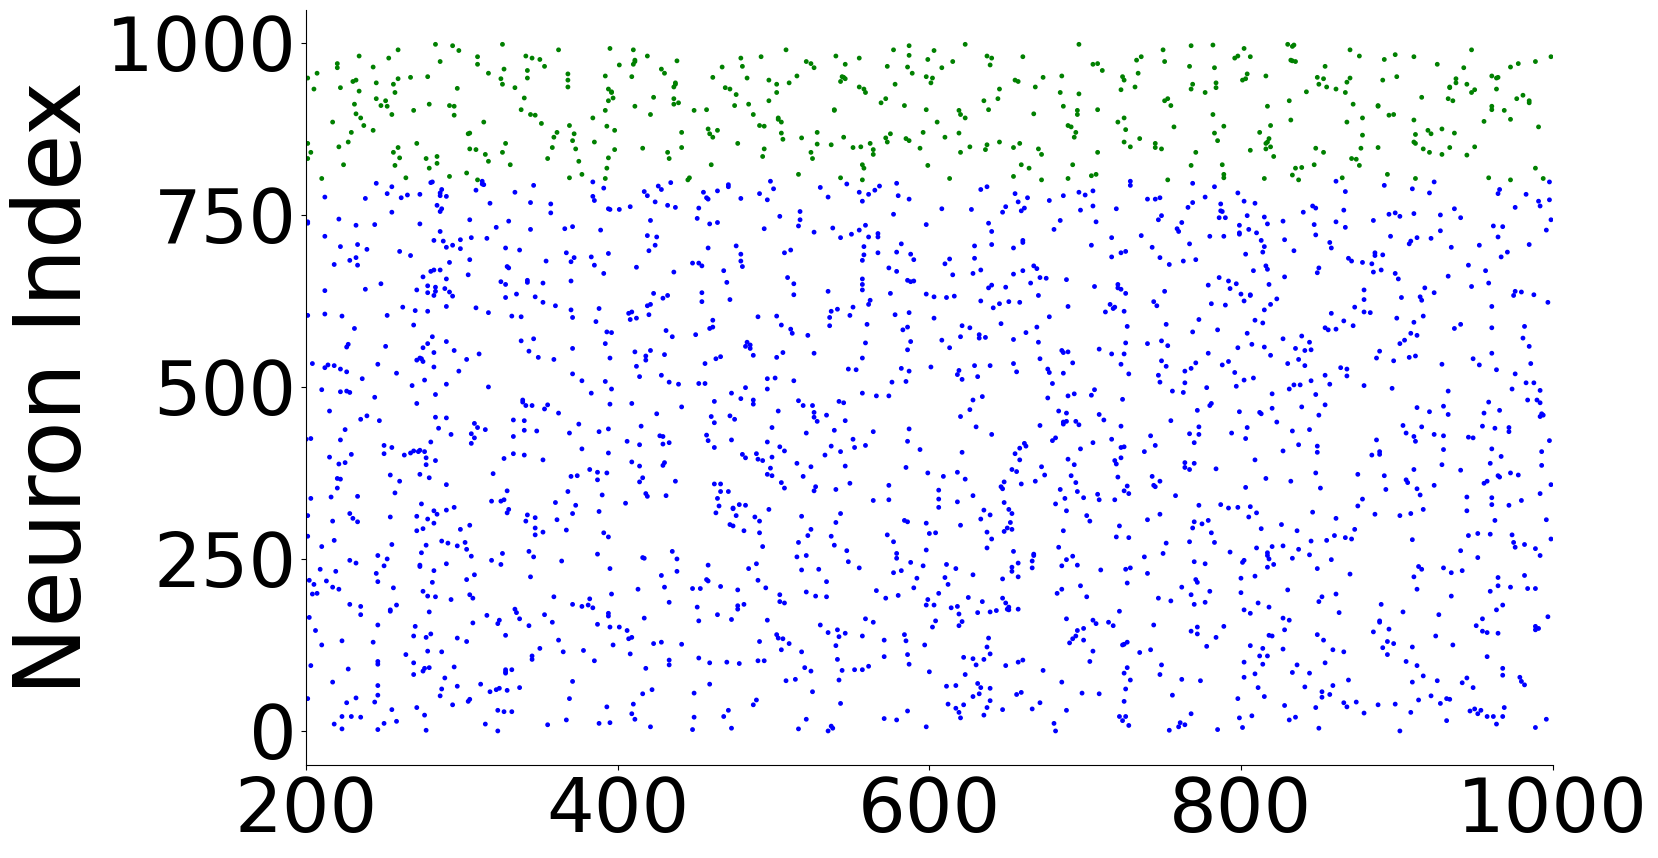

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Raster plot for CASE 2
# NOTE: update path as per local relative path
npz_path = "SNN_GA/results/snn_ga_1k/ex2_in2_20260410-004700/gen20_trial10_raster.npz"
Ne = 800                               # number of excitatory neurons
Ni = 200                               # number of inhibitory neurons
dt = 1.0 / 1000.0                      # seconds per step
start_index = 0                        
end_index = None                       

data = np.load(npz_path, allow_pickle=True)
firings_time = data["firings_time"]    # array of lists (per time step)
firings_neuron = data["firings_neuron"]  # array of lists (per neuron) – optional

# Build explicit (t, n) spike list
points = []
for t, fired in enumerate(firings_time):
    for n in fired:
        points.append((t, n))

if not points:
    raise RuntimeError("No spikes found in this trial.")

points = np.array(points)
t_idx = points[:, 0]
n_idx = points[:, 1]

# Correct GA analysis window: 200–1000 ms
dt = 1.0 / 1000.0
start_index = int(0.2 / dt)   # 200 ms
end_index   = int(1.0 / dt)   # 1000 ms

mask = (t_idx >= start_index) & (t_idx < end_index)
t_idx = t_idx[mask]
n_idx = n_idx[mask]

# Colour excitatory vs inhibitory
colors = np.where(n_idx >= Ne, "green", "blue")
plt.rcParams.update({
    "font.size": 54,            # was 18
    "axes.titlesize": 66,       # was 22
    "axes.labelsize": 66,       # was 22
    "xtick.labelsize": 54,      # was 18
    "ytick.labelsize": 54,      # was 18
    "legend.fontsize": 38,      # was 14
    "figure.titlesize": 66,     # was 22
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(18, 10))

# Time in ms
times_ms = t_idx * dt * 1000.0
ax.set_xlim(200, 1000)
ax.set_xticks([200, 400, 600, 800, 1000])
ax.set_xlabel("Time (ms)")

ax.scatter(times_ms, n_idx, s=6, c=colors)

# Styling
ax.set_ylabel("Neuron Index")
# no x-axis label
ax.set_xlabel("")

plt.tight_layout()
plt.show()


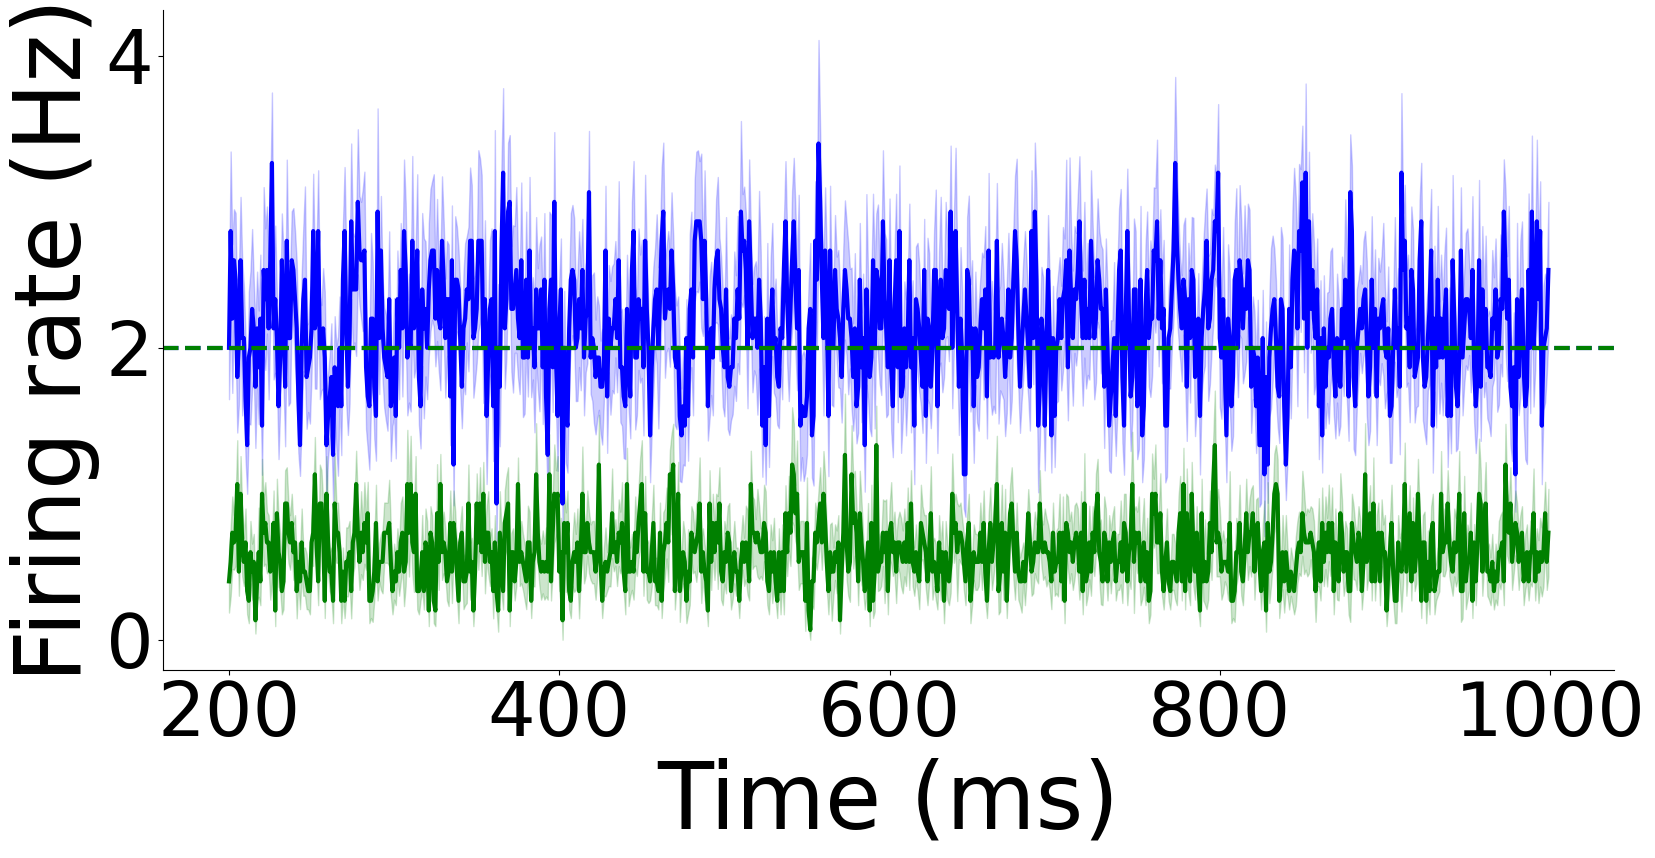

In [4]:
plt.rcParams.update({
    "font.size": 54,            
    "axes.titlesize": 66,       
    "axes.labelsize": 66,      
    "xtick.labelsize": 54,      
    "ytick.labelsize": 54,      
    "legend.fontsize": 38,      
    "figure.titlesize": 66,     
    "axes.spines.top": False,
    "axes.spines.right": False,
})
# Load averaged firing‑rate data
# NOTE: update path as per local relative path
path = "SNN_GA/results/snn_ga_1k/ex2_in2_20260410-004700/avg_firing_rates_gen20.npz"
data = np.load(path)

time_axis = data["time_axis"]
ex_mean = data["ex_mean"]
in_mean = data["in_mean"]
ex_sem = data["ex_sem"]
in_sem = data["in_sem"]

fig, ax = plt.subplots(figsize=(18,10))

# Excitatory
ax.plot(time_axis, ex_mean, color="blue", linewidth=3) #label="Excitatory neurons"
ax.fill_between(time_axis, ex_mean-ex_sem, ex_mean+ex_sem, color="blue", alpha=0.2)

# Inhibitory
ax.plot(time_axis, in_mean, color="green", linewidth=3) #label="Inhibitory neurons",
ax.fill_between(time_axis, in_mean-in_sem, in_mean+in_sem, color="green", alpha=0.2)

# Target lines (CASE 2 targets are both 2 Hz)
ax.axhline(2, color="blue", linestyle="--", linewidth=3)   # EX target
ax.axhline(2,  color="green", linestyle="--", linewidth=3)   # IN target

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Firing rate (Hz)")
# legend = ax.legend(
#     loc="center",
#     bbox_to_anchor=(0.80, 0.30),   # right side, ~3 Hz
#     bbox_transform=ax.transAxes,
#     frameon=False,
#     fontsize=38
# )
legend.set_in_layout(False)
plt.tight_layout()
plt.show()


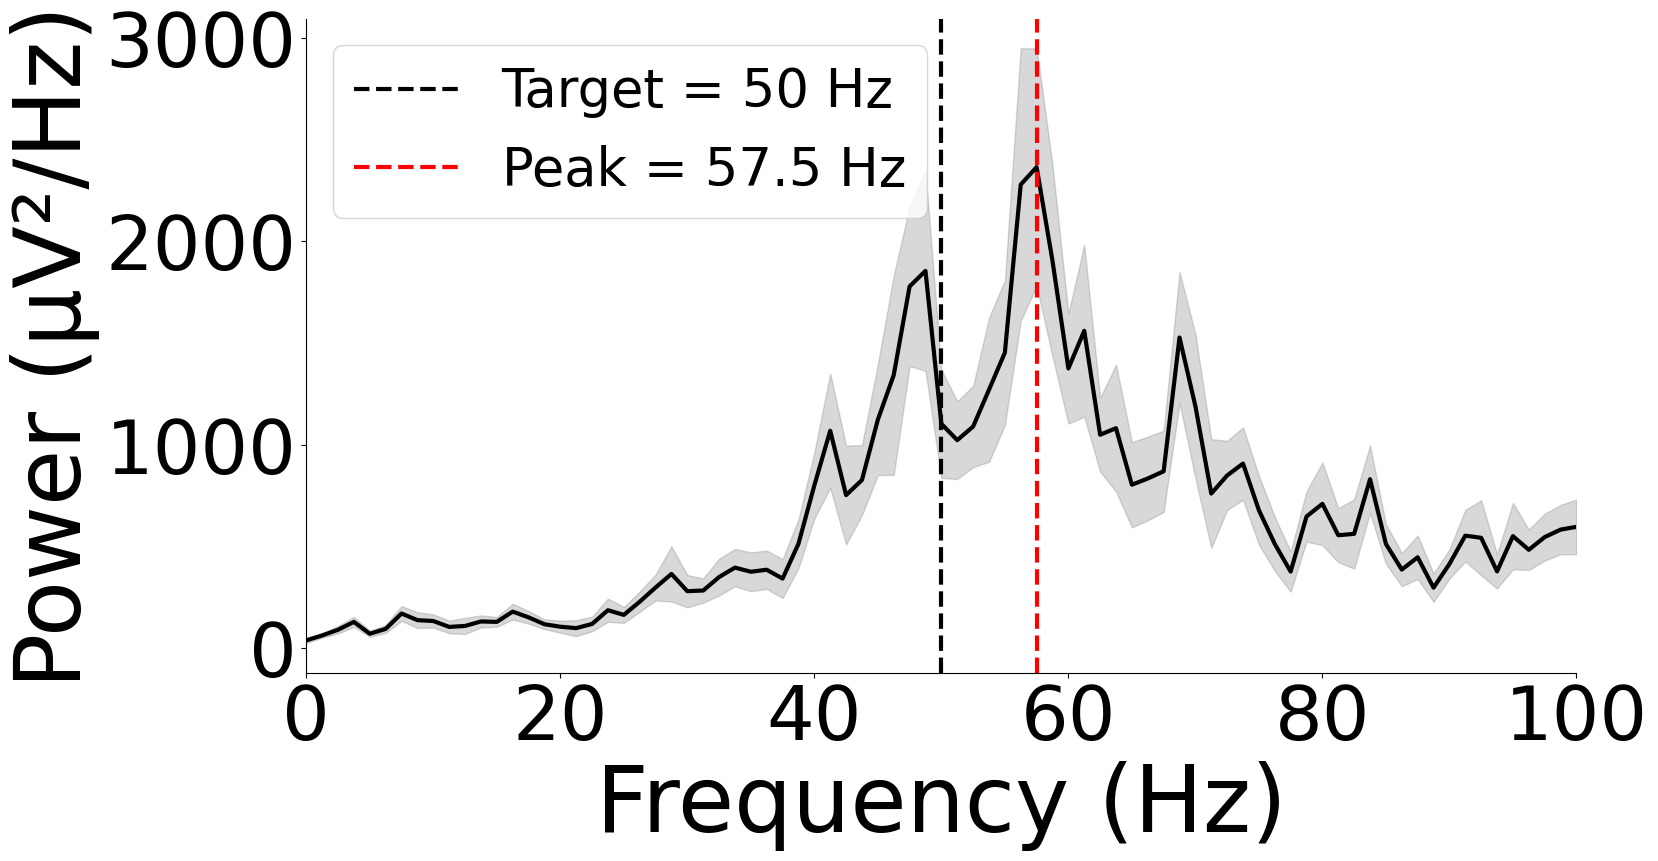

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 54,            
    "axes.titlesize": 66,       
    "axes.labelsize": 66,       
    "xtick.labelsize": 54,      
    "ytick.labelsize": 54,      
    "legend.fontsize": 38,      
    "figure.titlesize": 66,     
    "axes.spines.top": False,
    "axes.spines.right": False,
})
# Load PSD data
# NOTE: update path as per local relative path
path = "SNN_GA/results/snn_ga_1k/ex2_in2_20260410-004700/avg_psd_gen20.npz"
data = np.load(path)

freq = data["freq"]
psd_mean = data["psd_mean"]
psd_sem = data["psd_sem"]

# === COMPUTE ACTUAL PEAK FREQUENCY ===
peak_freq = freq[np.argmax(psd_mean)]

fig, ax = plt.subplots(figsize=(18,10))

# PSD curve
ax.plot(freq, psd_mean, color="black", linewidth=3)
ax.fill_between(freq, psd_mean-psd_sem, psd_mean+psd_sem, color="gray", alpha=0.3)

# === BLACK TARGET LINE AT 50 Hz ===
ax.axvline(50, color="black", linestyle="--", linewidth=3, label="Target = 50 Hz")

# === RED LINE AT ACTUAL PEAK FREQUENCY ===
ax.axvline(peak_freq, color="red", linestyle="--", linewidth=3, label=f"Peak = {peak_freq:.1f} Hz")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power (μV²/Hz)")
plt.xlim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()


CASE3 EXC 2HZ INH 10HZ

In [ ]:
# Load GA parameter file for CASE 3 (EXC 2 Hz, INH 10 Hz)
# NOTE: update path as per local relative path
params_path = "SNN_GA/results/snn_ga_1k/ex2_in10_20260409-225927/params.json"
with open(params_path) as f:
    params = json.load(f)
# Extract best candidate parameters
best = params["best_candidate"]
ge = best["ge"]
gi = best["gi"]
sp = best["sparsity"]
th_ex = best["thalamic_ex"]
th_in = best["thalamic_in"]
validated_comp = best["composite"]

In [ ]:
# Base seed offset for evaluation trials
SEED_BASE_EVAL = 1000

# GA target values for this case
ex_target = params["ex_target"]
in_target = params["in_target"]
psd_target = params["psd_peak_target"]

# Seeds used for repeated evaluation trials
trial_seeds = np.arange(params["trials_per_candidate"]) + SEED_BASE_EVAL

# Storage for trial‑wise metrics
ex_vals = []
in_vals = []
psd_vals = []

# Time resolution and analysis window (200–1000 ms)
dt = 1/1000
start_index = int(0.2/dt)
end_index = int(1.0/dt)
# PSD helper (same as previous cases)
def rfft_psd_peak(I_sum: np.ndarray, start_index: int, end_index: int, dt: float = 1.0/1000.0) -> Tuple[float, np.ndarray, np.ndarray]:
    """Return (peak_freq, faxis, Sxx) computed with consistent dt using rfft."""
    X = I_sum[start_index:end_index] - np.mean(I_sum[start_index:end_index])
    N = len(X)
    if N <= 1:
        return 0.0, np.array([0.0]), np.array([0.0])
    xf = np.fft.rfft(X * np.hanning(N))
    Sxx = np.real((2 * dt**2 / (N * dt)) * (xf * np.conj(xf)))
    faxis = np.fft.rfftfreq(N, d=dt)
    peak_freq = float(faxis[np.argmax(Sxx)])
    return peak_freq, faxis, Sxx
# Run evaluation trials using the GA‑optimised parameters
for seed in trial_seeds:
    model = SNN(ge=ge, gi=gi, sparsity=sp, thalamic_ex=th_ex, thalamic_in=th_in)
    result = model.run_network(seed=int(seed))
    s = result.score()
    ex_vals.append(s["ex_firing"])
    in_vals.append(s["in_firing"])
    peak, _, _ = rfft_psd_peak(result.I_sum, start_index, end_index, dt=dt)
    psd_vals.append(peak)
# Convert lists → arrays
ex_vals = np.array(ex_vals)
in_vals = np.array(in_vals)
psd_vals = np.array(psd_vals)

# Compute GA-space RMSEs
rmse_ex_raw = np.sqrt(np.mean((ex_vals - ex_target)**2))
rmse_in_raw = np.sqrt(np.mean((in_vals - in_target)**2))
rmse_psd_raw = np.sqrt(np.mean((psd_vals - psd_target)**2))

# Normalise by target values
ex_norm = rmse_ex_raw / ex_target
in_norm = rmse_in_raw / in_target
psd_norm = rmse_psd_raw / psd_target

print("GA-space coordinates for validated candidate:")
print("ex_norm =", ex_norm)
print("in_norm =", in_norm)
print("psd_norm =", psd_norm)

GA-space coordinates for validated candidate:
ex_norm = 0.03984630302278162
in_norm = 0.09953878013116293
psd_norm = 0.6377695508567338


In [ ]:
import plotly.graph_objects as go
# Load Pareto frontier for CASE 3
# NOTE: update path as per local relative path
path = "SNN_GA/results/snn_ga_1k/ex2_in10_20260409-225927/frontier_full.csv"
df = pd.read_csv(path)

# Extract normalised RMSE columns
exc = df["ex_firing_error_norm"]
inh = df["inhib_firing_error_norm"]
psd = df["psd_peak_error_norm"]

# Compute overall normalised RMSE
rmse_total = np.sqrt(exc**2 + inh**2 + psd**2)


fig = go.Figure()
# Frontier points
fig.add_trace(go.Scatter3d(
    x=exc,
    y=inh,
    z=psd,
    mode='markers',
    marker=dict(
        size=5,
        color=rmse_total,
        colorscale='Viridis',
        colorbar=dict(
            title = dict( text = "<br>Normalised Overall RMSE", side = "bottom" ),
            orientation="h",     # rotate 90 degrees
            x=0.5,               # center horizontally
            y=0.05,             # place below the plot
            thickness=20,
            len=0.5,
            tickmode="array",
            tickvals=[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0],
            ticktext=["1.0", "1.5", "2.0", "2.5", "3.0", "3.5", "4.0", "4.5"]
        ),
        opacity=0.9
    ),
    hovertemplate=(
        "RMSEexc: %{x:.3f}<br>"
        "RMSEinh: %{y:.3f}<br>"
        "RMSEfreq: %{z:.3f}<br>"
        "Overall: %{marker.color:.3f}<br>"
        "<extra></extra>"
    ),
    showlegend=False,
    name=""
))

# Highlight validated best point
fig.add_trace(go.Scatter3d(
    x=[ex_norm],
    y=[in_norm],
    z=[psd_norm],
    mode='markers',
    marker=dict(
        size=5,
        color=[validated_comp],
        colorscale='Viridis',
        opacity=1.0
    ),
    hovertemplate=(
        "Lowest overall RMSE of %{marker.color:.3f}<br>"
        "RMSEexc: %{x:.3f}<br>"
        "RMSEinh: %{y:.3f}<br>"
        "RMSEfreq: %{z:.3f}<br>"
        "<extra></extra>"
    ),
    showlegend=False,
    name=""
))

# Layout adjustments
fig.update_layout(
    scene=dict(
        domain=dict(
            x=[0.0, 1.0],
            y=[0.15, 1.0]   # only reserve 25% for colorbar, not 40–50%
        ),
        xaxis=dict(
            title=dict(text="Normalised excitatory RMSE", font=dict(size=26)),
            tickfont=dict(size=20)
        ),
        yaxis=dict(
            title=dict(text="Normalised inhibitory RMSE", font=dict(size=26)),
            tickfont=dict(size=20)
        ),
        zaxis=dict(
            title=dict(text="Normalised frequency RMSE", font=dict(size=26)),
            tickfont=dict(size=20)
        ),
    ),
    scene_camera=dict(
        eye=dict(x=1.8, y=2.2, z=1.5)   # lifts z-axis title
    ),
    margin=dict(l=0, r=0, t=0, b=0),   # remove unnecessary whitespace
    width=1100,
    height=950,
    showlegend=False
)

# Colorbar fonts
fig.data[0].marker.colorbar.title.font = dict(size=30)
fig.data[0].marker.colorbar.tickfont = dict(size=24)

fig.show()

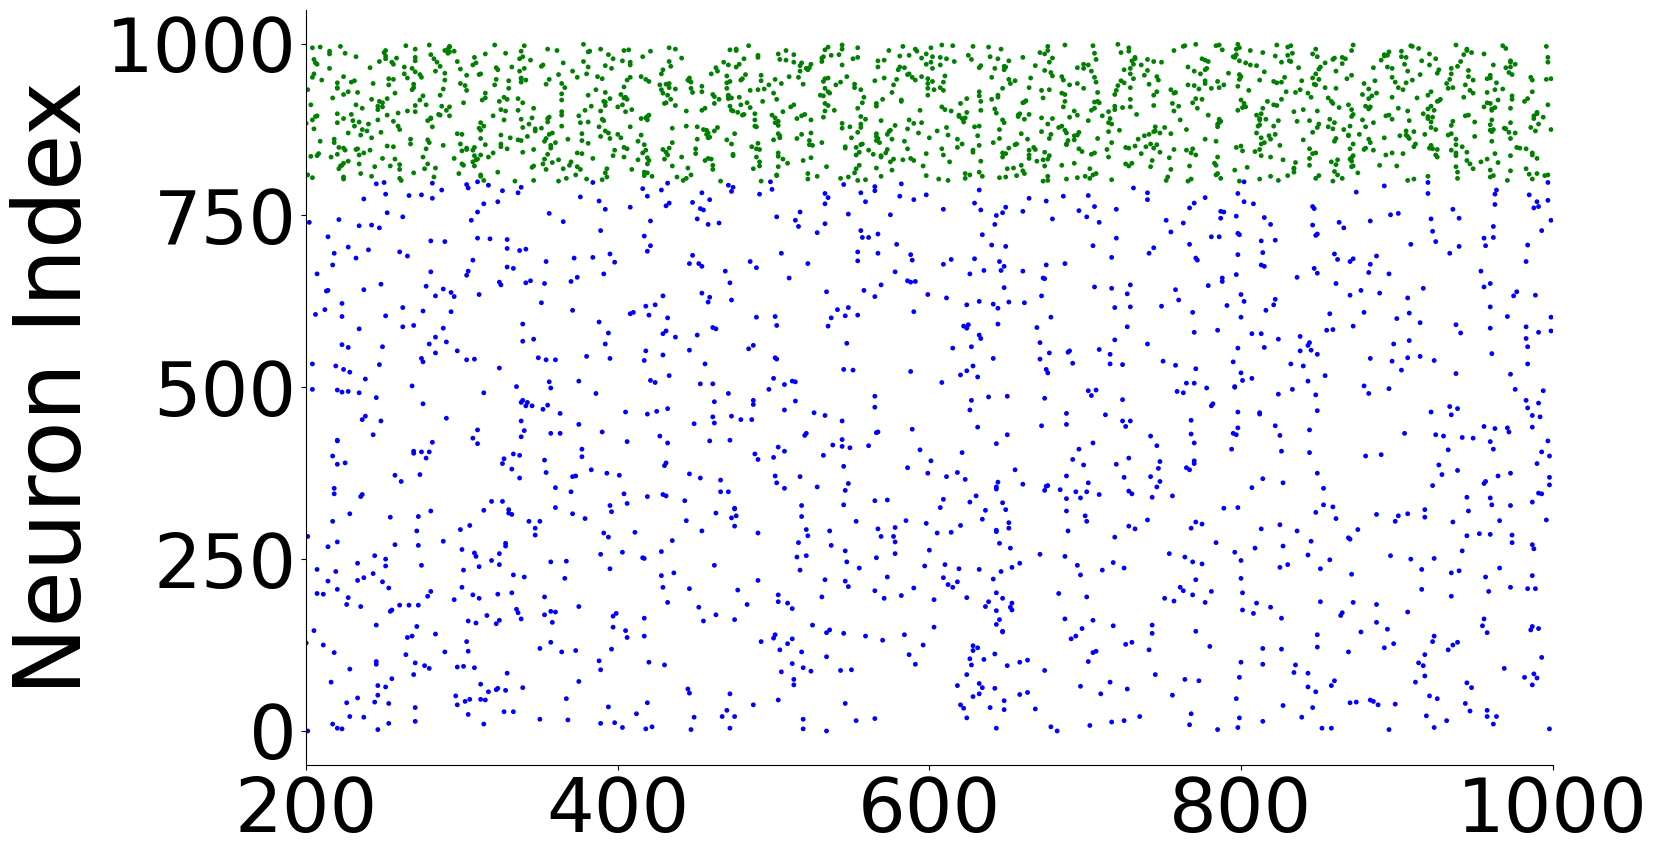

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Raster plot for CASE 3
# NOTE: update path as per local relative path
npz_path = "SNN_GA/results/snn_ga_1k/ex2_in10_20260409-225927/gen25_trial10_raster.npz"
Ne = 800                               # number of excitatory neurons
Ni = 200                               # number of inhibitory neurons
dt = 1.0 / 1000.0                      # seconds per step
start_index = 0                        
end_index = None                       

data = np.load(npz_path, allow_pickle=True)
firings_time = data["firings_time"]    # array of lists (per time step)
firings_neuron = data["firings_neuron"]  # array of lists (per neuron) – optional

# Build explicit (t, n) spike list
points = []
for t, fired in enumerate(firings_time):
    for n in fired:
        points.append((t, n))

if not points:
    raise RuntimeError("No spikes found in this trial.")

points = np.array(points)
t_idx = points[:, 0]
n_idx = points[:, 1]

# Correct GA analysis window: 200–1000 ms
dt = 1.0 / 1000.0
start_index = int(0.2 / dt)   # 200 ms
end_index   = int(1.0 / dt)   # 1000 ms

mask = (t_idx >= start_index) & (t_idx < end_index)
t_idx = t_idx[mask]
n_idx = n_idx[mask]


# Colour excitatory vs inhibitory
colors = np.where(n_idx >= Ne, "green", "blue")
plt.rcParams.update({
    "font.size": 54,            # was 18
    "axes.titlesize": 66,       # was 22
    "axes.labelsize": 66,       # was 22
    "xtick.labelsize": 54,      # was 18
    "ytick.labelsize": 54,      # was 18
    "legend.fontsize": 38,      # was 14
    "figure.titlesize": 66,     # was 22
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(18, 10))

# Time in ms
times_ms = t_idx * dt * 1000.0
ax.set_xlim(200, 1000)
ax.set_xticks([200, 400, 600, 800, 1000])
ax.set_xlabel("Time (ms)")

ax.scatter(times_ms, n_idx, s=6, c=colors)

# Styling
ax.set_ylabel("Neuron Index")
# no x-axis label
ax.set_xlabel("")

plt.tight_layout()
plt.show()


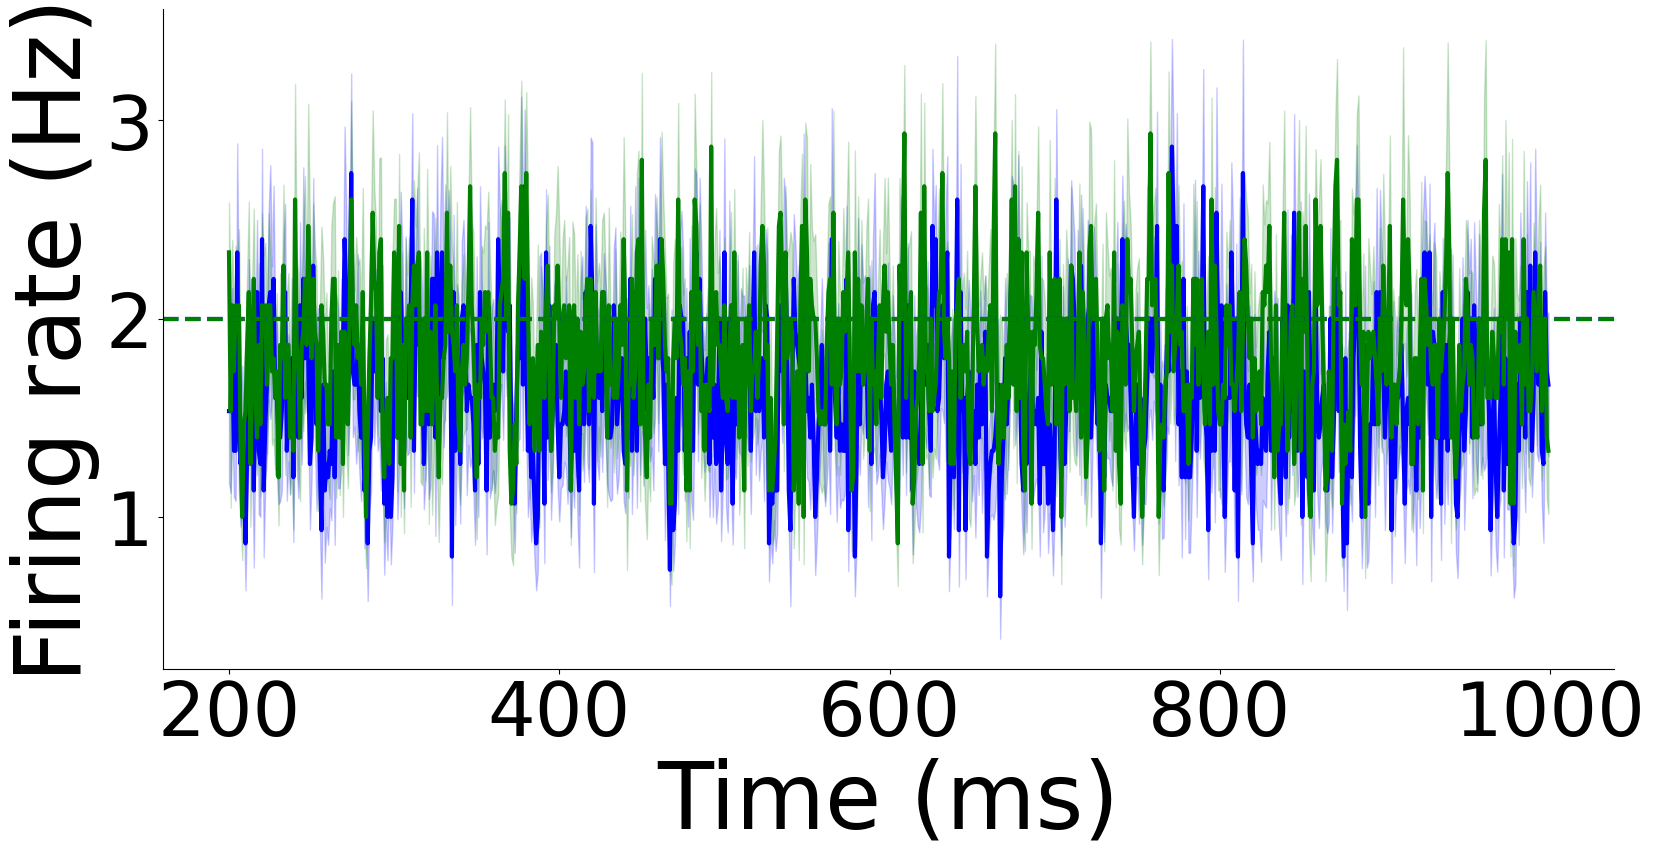

In [5]:
plt.rcParams.update({
    "font.size": 54,            
    "axes.titlesize": 66,       
    "axes.labelsize": 66,      
    "xtick.labelsize": 54,      
    "ytick.labelsize": 54,      
    "legend.fontsize": 38,      
    "figure.titlesize": 66,     
    "axes.spines.top": False,
    "axes.spines.right": False,
})
# Load averaged firing‑rate data
# NOTE: update path as per local relative path
path = "SNN_GA/results/snn_ga_1k/ex2_in10_20260409-225927/avg_firing_rates_gen25.npz"
data = np.load(path)

time_axis = data["time_axis"]
ex_mean = data["ex_mean"]
in_mean = data["in_mean"]
ex_sem = data["ex_sem"]
in_sem = data["in_sem"]

fig, ax = plt.subplots(figsize=(18,10))

# Excitatory
ax.plot(time_axis, ex_mean, color="blue", linewidth=3) #label="Excitatory neurons"
ax.fill_between(time_axis, ex_mean-ex_sem, ex_mean+ex_sem, color="blue", alpha=0.2)

# Inhibitory
ax.plot(time_axis, in_mean, color="green", linewidth=3) #label="Inhibitory neurons",
ax.fill_between(time_axis, in_mean-in_sem, in_mean+in_sem, color="green", alpha=0.2)

# Target lines for CASE 3 (EXC=2 Hz, INH=10 Hz)
ax.axhline(2, color="blue", linestyle="--", linewidth=3)   # EX target
ax.axhline(2,  color="green", linestyle="--", linewidth=3)   # IN target

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Firing rate (Hz)")
# legend = ax.legend(
#     loc="center",
#     bbox_to_anchor=(0.80, 0.30),   # right side, ~3 Hz
#     bbox_transform=ax.transAxes,
#     frameon=False,
#     fontsize=38
# )
legend.set_in_layout(False)
plt.tight_layout()
plt.show()


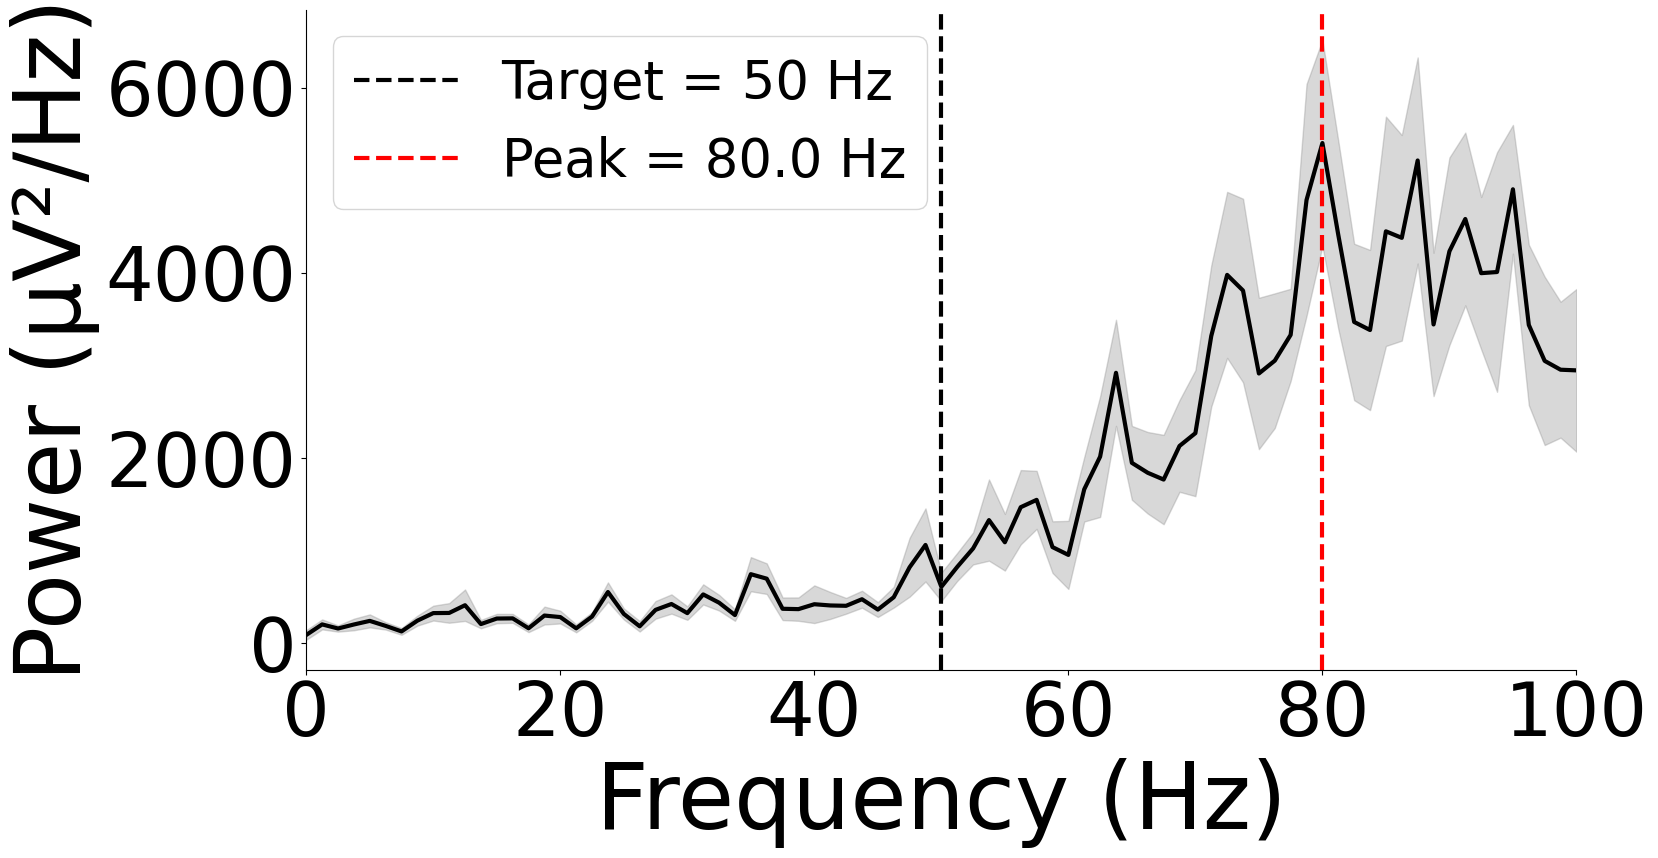

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 54,            
    "axes.titlesize": 66,       
    "axes.labelsize": 66,       
    "xtick.labelsize": 54,      
    "ytick.labelsize": 54,      
    "legend.fontsize": 38,      
    "figure.titlesize": 66,     
    "axes.spines.top": False,
    "axes.spines.right": False,
})
# Load PSD data
# NOTE: update path as per local relative path
path = "SNN_GA/results/snn_ga_1k/ex2_in10_20260409-225927/avg_psd_gen25.npz"
data = np.load(path)

freq = data["freq"]
psd_mean = data["psd_mean"]
psd_sem = data["psd_sem"]

# === COMPUTE ACTUAL PEAK FREQUENCY ===
peak_freq = freq[np.argmax(psd_mean)]

fig, ax = plt.subplots(figsize=(18,10))

# PSD curve
ax.plot(freq, psd_mean, color="black", linewidth=3)
ax.fill_between(freq, psd_mean-psd_sem, psd_mean+psd_sem, color="gray", alpha=0.3)

# === BLACK TARGET LINE AT 50 Hz ===
ax.axvline(50, color="black", linestyle="--", linewidth=3, label="Target = 50 Hz")

# === RED LINE AT ACTUAL PEAK FREQUENCY ===
ax.axvline(peak_freq, color="red", linestyle="--", linewidth=3, label=f"Peak = {peak_freq:.1f} Hz")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power (μV²/Hz)")
plt.xlim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()
